# Variational Equilibrium in Cognitive Systems — Simulation of Predictions H1–H4

**Companion notebook to:** *Variational Equilibrium as an Organizing Principle of Natural and
Artificial Cognitive Systems: From Objective Maximization to Balanced Persistence*
(Article 2, target: *Cognitive Systems Research*).

**Author:** H. Hamam

---

### What this notebook does

Section 6.6 of the manuscript states four predictions (H1–H4) that are intended to
distinguish UVIF from expected-free-energy accounts and from resource-rational analysis.
This notebook implements the five forces as explicit functions and tests whether those
four predictions hold **of the framework itself** — that is, whether the framework's own
dynamics produce the signatures the manuscript attributes to it.

### What this notebook does *not* do

It is a simulation, not evidence about real cognitive systems. Establishing that H1–H4
hold of human or animal cognition requires the experimental designs described in
Section 10, and none of them are performed here. Accordingly:

* every result below is a statement about a model whose functional forms were chosen by
  the author;
* a confirmed prediction here means the framework is internally coherent and that the
  predicted signature is well defined and measurable — not that it is true;
* a *failed* prediction here is informative, and one of the four did fail on first
  implementation (see Section 5). That failure is retained in the notebook rather than
  edited out.

### Methodological rules

These follow from a review of the earlier UVIF notebooks, where the operating threshold
was selected on the test set and the scoring weights were hand-set constants:

1. **Nothing is tuned on what it is scored on.** Environments are split once into disjoint
   calibration and evaluation sets. Every comparator's free parameters are fitted on
   calibration and all reported numbers come from evaluation.
2. **No hand-set weight vector decides a headline result.** State dependence lives inside
   the force functions. Where a comparator has free weights, they are searched densely and
   the search range is widened until the fit stops improving, so the comparator is not
   understated.
3. **Seed-fixed and deterministic.** Policy search is an exhaustive grid argmax, not a
   stochastic optimiser.
4. **Section 8 sweeps every model constant** to show which conclusions survive and which
   are artifacts of the chosen values.

## 1. Setup

In [1]:
# ============================================================
# 1. Environment, output folders, reproducibility
# ============================================================
import os, json, itertools, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

PROJECT_NAME = "UVIF_CognitiveEquilibrium_Article2"

try:                                    # Colab
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/Outputs") / PROJECT_NAME
except Exception:                       # local / headless execution
    BASE_DIR = Path("Outputs") / PROJECT_NAME

FIG_DIR, TABLE_DIR, OTHER_DIR = BASE_DIR/"figures", BASE_DIR/"tables", BASE_DIR/"others"
for d in (FIG_DIR, TABLE_DIR, OTHER_DIR):
    d.mkdir(parents=True, exist_ok=True)

SUMMARY = BASE_DIR / "outputs_summary.txt"
SUMMARY.write_text("UVIF Cognitive Equilibrium - Article 2 simulation\n", encoding="utf-8")

def log(msg):
    print(msg)
    with open(SUMMARY, "a", encoding="utf-8") as f:
        f.write(str(msg) + "\n")

SEED = 20260916
RNG  = np.random.default_rng(SEED)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

log(f"[INFO] numpy {np.__version__} | seed {SEED}")
log(f"[INFO] outputs -> {BASE_DIR}")

[INFO] numpy 2.4.4 | seed 20260916
[INFO] outputs -> Outputs/UVIF_CognitiveEquilibrium_Article2


## 2. The five forces

A policy is $\pi=(e,a)$: epistemic effort $e$ and action aggressiveness $a$, both in $[0,1]$.
An environment state is $s=(R,T,H)$: resource level, threat level, and horizon.

The five forces of Section 4 are implemented as explicit functions of $(\pi, s)$:

| Force | Symbol | Implementation |
|---|---|---|
| Epistemic pull | $\mathcal{E}_{\mathrm{pull}}$ | information gained by effort $e$ |
| Action efficiency | $\mathcal{A}_{\mathrm{eff}}$ | timely correct action; deliberation delays it |
| Computational drag | $\mathcal{D}_{\mathrm{drag}}$ | cost of inference, rising as resources deplete |
| Protective shield | $\mathcal{P}_{\mathrm{prot}}$ | exposure to unrecoverable loss |
| Sustainability | $\mathcal{S}_{\mathrm{sus}}$ | infeasibility of the policy over horizon $H$ |

**State dependence is placed inside the force functions** — $1/R$ in the drag, $T$ in the
protective term, $H$ in the sustainability term — and *not* in a hand-tuned weight vector.
This matters for H1: the comparator there is an agent whose weights are free but fixed, so
the test is whether any such agent can imitate UVIF across states.

In [2]:
# ============================================================
# 2. The five forces, the equilibrium objective, and policy search
# ============================================================
KAPPA = 3.0     # how fast information accrues with epistemic effort
LAM   = 0.35    # deliberation delay penalty on timeliness
CD    = 0.55    # unit cost of inference
RHO   = 0.90    # exposure to unrecoverable loss
CS    = 0.55    # per-step resource drawdown
REGEN = 0.30    # per-step resource replenishment
TAU_H = 25.0    # horizon over which unsustainability makes itself felt
RMIN  = 0.12    # floor so drag stays finite

def accuracy(e):
    """Belief quality attained by epistemic effort e."""
    return 0.5 + 0.45 * (1.0 - np.exp(-KAPPA * e))

def f_epistemic(e):
    """E_pull: information gained."""
    return 1.0 - np.exp(-KAPPA * e)

def f_action(e, a):
    """A_eff: timely, correct action. Deliberation delays it."""
    return a * (2.0 * accuracy(e) - 1.0) - LAM * e * a

def f_drag(e, R):
    """D_drag: cost of inference, which rises as resources deplete."""
    return CD * e ** 2 / np.maximum(R, RMIN)

def f_protect(e, a, T):
    """P_prot: probability-weighted unrecoverable loss.
    Aggressive action taken while poorly informed, under threat, is what
    endangers states the system cannot recover."""
    return RHO * a * T * (1.0 - accuracy(e))

def f_sustain(e, a, R, H):
    """S_sus: infeasibility of sustaining this policy over horizon H.

    A policy whose per-step drawdown exceeds replenishment is not viable
    indefinitely. The penalty saturates with the horizon: over a single
    episode an unsustainable policy costs almost nothing, which is precisely
    why a per-episode objective cannot express this force (prediction H2).
    """
    overdraw = np.maximum(0.0, CS * (e + a) - REGEN)
    return overdraw * (1.0 - np.exp(-H / TAU_H))

def uvif_objective(e, a, R, T, H, mask=(1, 1, 1, 1, 1)):
    """Net value at Variational Equilibrium. `mask` ablates individual forces (H4)."""
    mE, mA, mD, mP, mS = mask
    return (mE * f_epistemic(e)
            + mA * f_action(e, a)
            - mD * f_drag(e, R)
            - mP * f_protect(e, a, T)
            - mS * f_sustain(e, a, R, H))

# ----------------------------------------------------------------------------
# 2. Policy search on a fixed grid (deterministic, no optimiser stochasticity).
# ----------------------------------------------------------------------------
GRID = np.linspace(0.0, 1.0, 51)
EE, AA = np.meshgrid(GRID, GRID, indexing="ij")

def best_policy(R, T, H, mask=(1, 1, 1, 1, 1)):
    V = uvif_objective(EE, AA, R, T, H, mask)
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j], V[i, j]

## 3. Environment sets — disjoint calibration and evaluation

In [3]:
# ============================================================
# 3. Calibration / evaluation split (done once, seed-fixed)
# ============================================================
def environment_sets():
    R_all = np.round(np.linspace(0.20, 1.00, 9), 3)
    T_all = np.round(np.linspace(0.10, 0.90, 5), 3)
    H_all = np.array([5, 20, 60, 150], dtype=float)
    allenv = np.array(list(itertools.product(R_all, T_all, H_all)), dtype=float)
    idx = RNG.permutation(len(allenv))
    cut = len(allenv) // 2
    return allenv[idx[:cut]], allenv[idx[cut:]]

CALIB, EVAL = environment_sets()
log(f"[SPLIT] calibration environments: {len(CALIB)} | evaluation environments: {len(EVAL)}")
assert not set(map(tuple, CALIB)) & set(map(tuple, EVAL)), "splits must be disjoint"
log("[SPLIT] disjointness verified")

[SPLIT] calibration environments: 90 | evaluation environments: 90
[SPLIT] disjointness verified


## 4. H1 — State-dependent force weighting

> *If the balance between epistemic and pragmatic drives is a state variable rather than a
> model parameter, then manipulating a system's resource state while holding the task's
> information structure and reward structure fixed should shift behaviour.*

**Test.** The comparator is an agent that maximises a fixed linear scalarisation of the five
forces with free non-negative weights $w$, each force evaluated at a fixed reference state.
If UVIF were merely a scalarisation in disguise, some $w$ would reproduce its policy in
every environment. We fit $w$ on the calibration environments and report the residual on
the held-out evaluation environments.

In [4]:
# ============================================================
# 4. H1: can a fixed-weight scalarisation imitate UVIF?
# ============================================================
R_REF, T_REF, H_REF = 0.60, 0.50, 40.0

def scalarised_policy(w):
    """Free weights, but forces frozen at a reference state: the weights, not the
    state, are all that can shape this agent's trade-off."""
    V = (w[0]*f_epistemic(EE) + w[1]*f_action(EE, AA)
         - w[2]*f_drag(EE, R_REF) - w[3]*f_protect(EE, AA, T_REF)
         - w[4]*f_sustain(EE, AA, R_REF, H_REF))
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j]

def policy_table(envs):
    return np.array([best_policy(R, T, H)[:2] for R, T, H in envs])

uvif_calib, uvif_eval = policy_table(CALIB), policy_table(EVAL)

def fit_fixed_weights(target, steps=np.linspace(0.0, 2.0, 9)):
    best, best_err = None, np.inf
    for w in itertools.product(steps, repeat=5):
        if sum(w) == 0:
            continue
        e_s, a_s = scalarised_policy(w)
        err = np.mean((target[:,0]-e_s)**2 + (target[:,1]-a_s)**2)
        if err < best_err:
            best, best_err = np.array(w), err
    return best, best_err

w_star, mse_calib = fit_fixed_weights(uvif_calib)
e_fix, a_fix = scalarised_policy(w_star)
mse_eval = np.mean((uvif_eval[:,0]-e_fix)**2 + (uvif_eval[:,1]-a_fix)**2)
var_eval = np.mean(np.sum((uvif_eval - uvif_eval.mean(axis=0))**2, axis=1))

log("\n[H1] best fixed weight vector w* = " + np.array2string(w_star, precision=2))
log(f"[H1] that agent plays a single policy everywhere: (e,a) = ({e_fix:.2f}, {a_fix:.2f})")
log(f"[H1] calibration MSE = {mse_calib:.4f} | held-out evaluation MSE = {mse_eval:.4f}")
log(f"[H1] mean-policy baseline error = {var_eval:.4f}")
log(f"[H1] ratio of fixed-weight error to that baseline = {mse_eval/var_eval:.2f}x")
log("[H1] a ratio above 1.0 means the best fixed-weight agent fits the held-out UVIF")
log("[H1] policies WORSE than simply predicting the mean UVIF policy everywhere.")
log(f"[H1] distinct UVIF policies across {len(EVAL)} evaluation environments: "
    f"{len(np.unique(uvif_eval, axis=0))}")


[H1] best fixed weight vector w* = [0.   1.   1.   0.5  0.75]
[H1] that agent plays a single policy everywhere: (e,a) = (0.18, 0.38)
[H1] calibration MSE = 0.2784 | held-out evaluation MSE = 0.2627
[H1] mean-policy baseline error = 0.1731
[H1] ratio of fixed-weight error to that baseline = 1.52x
[H1] a ratio above 1.0 means the best fixed-weight agent fits the held-out UVIF
[H1] policies WORSE than simply predicting the mean UVIF policy everywhere.
[H1] distinct UVIF policies across 90 evaluation environments: 33


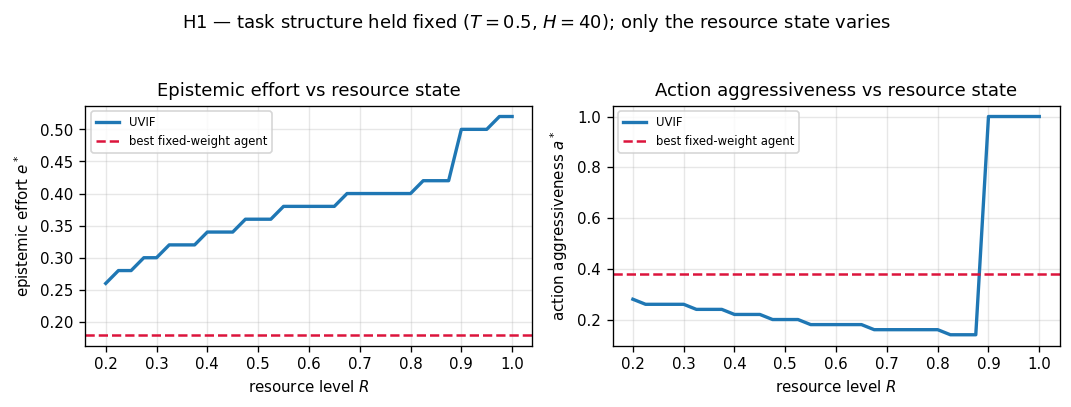

In [5]:
# ------------------------------------------------------------
# H1 figure: policy shifts with resource level, at fixed task structure
# ------------------------------------------------------------
R_line = np.linspace(0.20, 1.00, 33)
pol = np.array([best_policy(R, 0.5, 40.0)[:2] for R in R_line])

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(R_line, pol[:,0], lw=2, label="UVIF")
ax[0].axhline(e_fix, ls="--", lw=1.5, color="crimson", label="best fixed-weight agent")
ax[0].set_xlabel("resource level $R$"); ax[0].set_ylabel("epistemic effort $e^*$")
ax[0].set_title("Epistemic effort vs resource state"); ax[0].legend(fontsize=7)

ax[1].plot(R_line, pol[:,1], lw=2, label="UVIF")
ax[1].axhline(a_fix, ls="--", lw=1.5, color="crimson", label="best fixed-weight agent")
ax[1].set_xlabel("resource level $R$"); ax[1].set_ylabel("action aggressiveness $a^*$")
ax[1].set_title("Action aggressiveness vs resource state"); ax[1].legend(fontsize=7)

fig.suptitle("H1 — task structure held fixed ($T=0.5$, $H=40$); only the resource state varies", y=1.04)
fig.tight_layout(); fig.savefig(FIG_DIR/"figure_H1_state_dependent_weighting.png", bbox_inches="tight")
plt.show()

## 5. H3 — Irreversibility is not a large negative utility

> *If $\mathcal{P}_{\mathrm{prot}}$ is qualitatively distinct from a large negative utility,
> then choices involving unrecoverable outcomes should not be reproducible by any monotone
> rescaling of the utilities attached to recoverable ones.*

### 5.1 A failed first implementation, retained

The first version of this experiment represented $\mathcal{P}_{\mathrm{prot}}$ as an additive
penalty term in the objective, and then asked whether a monotone rescaling of that term
could reproduce the resulting policies. It could — **exactly**, with held-out MSE of
$0.0000$ at $b=1,\,g=1$.

That is the correct answer to the wrong question. An additive penalty *is* a large negative
utility, so the first implementation did not instantiate H3 at all; it asked whether a
rescaling of a penalty can reproduce that same penalty. The perfect fit was the diagnostic
that exposed the error.

### 5.2 The corrected test

The manuscript distinguishes the admissibility constraints $\mathcal{C}_{\mathrm{adm}}$ from
the five forces. Implemented faithfully, exposure to unrecoverable loss is a **ceiling**:
policies exceeding it are inadmissible whatever their payoff. A hard constraint introduces
a discontinuity that a smooth monotone penalty must approximate rather than match.

In [6]:
# ============================================================
# 5. H3: admissibility constraint vs monotone utility penalty
# ============================================================
P_MAX = 0.15     # ceiling on tolerated probability of unrecoverable loss

def constrained_policy(R, T, H):
    """UVIF with protection as an admissibility constraint."""
    V = f_epistemic(EE) + f_action(EE, AA) - f_drag(EE, R) - f_sustain(EE, AA, R, H)
    V = np.where(f_protect(EE, AA, T) <= P_MAX, V, -np.inf)
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j]

def penalised_policy(b, g, R, T, H):
    """Comparator: irreversibility folded into utility as a monotone penalty b*loss**g."""
    loss = f_protect(EE, AA, T)
    V = (f_epistemic(EE) + f_action(EE, AA) - f_drag(EE, R)
         - f_sustain(EE, AA, R, H) - b*np.power(np.maximum(loss, 0.0), g))
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j]

con_calib = np.array([constrained_policy(*e) for e in CALIB])
con_eval  = np.array([constrained_policy(*e) for e in EVAL])
var_con   = np.mean(np.sum((con_eval - con_eval.mean(axis=0))**2, axis=1))

def fit_penalty(target, blo, bhi, glo, ghi, nb, ng):
    best, best_err = None, np.inf
    for b in np.linspace(blo, bhi, nb):
        for g in np.linspace(glo, ghi, ng):
            pred = np.array([penalised_policy(b, g, R, T, H) for R, T, H in CALIB])
            err = np.mean(np.sum((pred - target)**2, axis=1))
            if err < best_err:
                best, best_err = (b, g), err
    return best, best_err

# The comparator must not be understated: widen the search until the fit stops improving.
h3_rows = []
for tag, args in [("narrow",    (0.1,  12.0, 0.25,  3.5, 30, 26)),
                  ("widened",   (0.1,  60.0, 0.25, 10.0, 34, 30)),
                  ("very wide", (0.1, 400.0, 0.25, 25.0, 30, 26))]:
    (b, g), ec = fit_penalty(con_calib, *args)
    pred = np.array([penalised_policy(b, g, R, T, H) for R, T, H in EVAL])
    ee   = np.mean(np.sum((pred - con_eval)**2, axis=1))
    h3_rows.append({"search range": tag, "b*": round(b,2), "g*": round(g,2),
                    "calib MSE": round(ec,4), "eval MSE": round(ee,4),
                    "unexplained %": round(100*ee/var_con,1),
                    "exact match %": round(100*np.mean(np.all(np.isclose(pred, con_eval),axis=1)),1)})

h3_df = pd.DataFrame(h3_rows)
h3_df.to_csv(TABLE_DIR/"table_H3_monotone_penalty_fits.csv", index=False)
log("\n[H3] best monotone penalty as the search range widens:")
log(h3_df.to_string(index=False))
display(h3_df)


[H3] best monotone penalty as the search range widens:
search range     b*   g*  calib MSE  eval MSE  unexplained %  exact match %
      narrow   8.31 3.24     0.0005    0.0237           14.8           87.8
     widened  50.92 3.95     0.0001    0.0237           14.8           85.6
   very wide 400.00 5.20     0.0001    0.0168           10.5           86.7


,search range,b*,g*,calib MSE,eval MSE,unexplained %,exact match %
0,narrow,8.31,3.24,0.0005,0.0237,14.8,87.8
1,widened,50.92,3.95,0.0001,0.0237,14.8,85.6
2,very wide,400.00,5.20,0.0001,0.0168,10.5,86.7


**Reading the H3 result.** The residual falls as the search widens but does not vanish, and
the fitted coefficient $b^\ast$ runs to the ceiling of whatever range it is given. This is
the expected signature: a steep enough penalty *approximates* a hard constraint, converging
to it only in the limit $b\to\infty$.

The defensible claim is therefore narrow, and the manuscript should state it this way:
**no finite monotone rescaling reproduces the constrained policy, and the approximating
family requires an unbounded coefficient.** The stronger claim — that no monotone rescaling
*can* reproduce it — is false as a limit statement and should not be made.

## 6. H2 — Sustainability effects beyond the episode

> *If $\mathcal{S}_{\mathrm{sus}}$ is a genuine force rather than a long-horizon utility term,
> agents told the regime will be sustained indefinitely should adopt systematically
> different — and locally suboptimal — strategies from agents facing an identical single
> episode.*


[H2] single-episode policy   (e,a) = (0.52, 1.00)
[H2] sustained-regime policy (e,a) = (0.38, 0.16)
[H2] per-episode value of the sustained policy is lower: 0.611 vs 0.985  (locally suboptimal by 0.374)
[H2] resource after 150 steps: single-episode policy 0.000 (0 = viability failure at step 1) | sustained policy 1.000


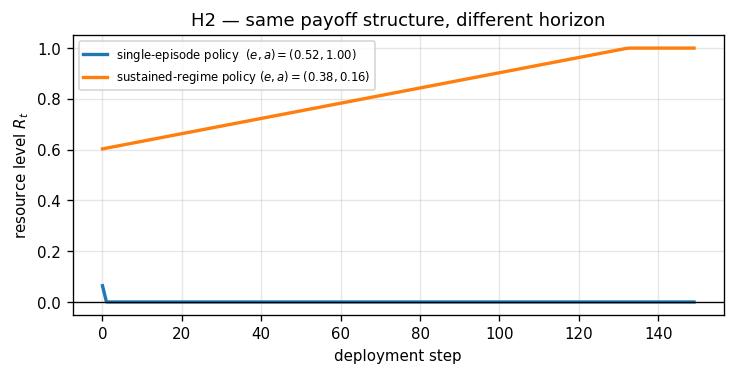

In [7]:
# ============================================================
# 6. H2: identical payoff structure, different horizon
# ============================================================
def rollout(e, a, R0=0.6, steps=150):
    R, traj = R0, []
    for _ in range(steps):
        R = min(1.0, R + REGEN - CS*(e + a))
        traj.append(max(R, 0.0))
        if R <= 0:
            traj += [0.0]*(steps - len(traj)); break
    return np.array(traj)

e_s, a_s, v_s = best_policy(0.6, 0.5, 1.0)      # single episode
e_l, a_l, v_l = best_policy(0.6, 0.5, 150.0)    # sustained regime

traj_s, traj_l = rollout(e_s, a_s), rollout(e_l, a_l)
log(f"\n[H2] single-episode policy   (e,a) = ({e_s:.2f}, {a_s:.2f})")
log(f"[H2] sustained-regime policy (e,a) = ({e_l:.2f}, {a_l:.2f})")
log(f"[H2] per-episode value of the sustained policy is lower: {v_l:.3f} vs {v_s:.3f}"
    f"  (locally suboptimal by {v_s-v_l:.3f})")
log(f"[H2] resource after 150 steps: single-episode policy {traj_s[-1]:.3f} "
    f"(0 = viability failure at step {int(np.argmax(traj_s<=0))}) | sustained policy {traj_l[-1]:.3f}")

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(traj_s, lw=2, label=f"single-episode policy  $(e,a)=({e_s:.2f},{a_s:.2f})$")
ax.plot(traj_l, lw=2, label=f"sustained-regime policy $(e,a)=({e_l:.2f},{a_l:.2f})$")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("deployment step"); ax.set_ylabel("resource level $R_t$")
ax.set_title("H2 — same payoff structure, different horizon"); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR/"figure_H2_horizon_contrast.png", bbox_inches="tight")
plt.show()

## 7. H4 — Per-force failure signatures

> *Selectively suppressing a single force should produce a distinguishable failure mode.*

Each ablated agent is **scored with the intact objective** throughout: an agent missing a
force is judged by what its behaviour actually costs, not by its own truncated objective.
Deployment curves are long-horizon by construction — mixing short-horizon environments in
here would let an ablated agent out-survive the intact one for the wrong reason.


[H4] deployment value under single-force ablation (intact scoring):
         ablation    t=0   t=10   t=50  t=149   mean
           intact +0.608 +0.609 +0.609 +0.626 +0.615
no epistemic pull +0.345 +0.486 +0.499 +0.521 +0.504
    no protection +0.606 +0.585 +0.471 +0.471 +0.491
          no drag +0.518 +0.474 -0.057 -1.632 -0.784
no sustainability +0.456 -0.902 -0.902 -0.902 -0.887


,ablation,t=0,t=10,t=50,t=149,mean
0,intact,+0.608,+0.609,+0.609,+0.626,+0.615
1,no epistemic pull,+0.345,+0.486,+0.499,+0.521,+0.504
2,no protection,+0.606,+0.585,+0.471,+0.471,+0.491
3,no drag,+0.518,+0.474,-0.057,-1.632,-0.784
4,no sustainability,+0.456,-0.902,-0.902,-0.902,-0.887


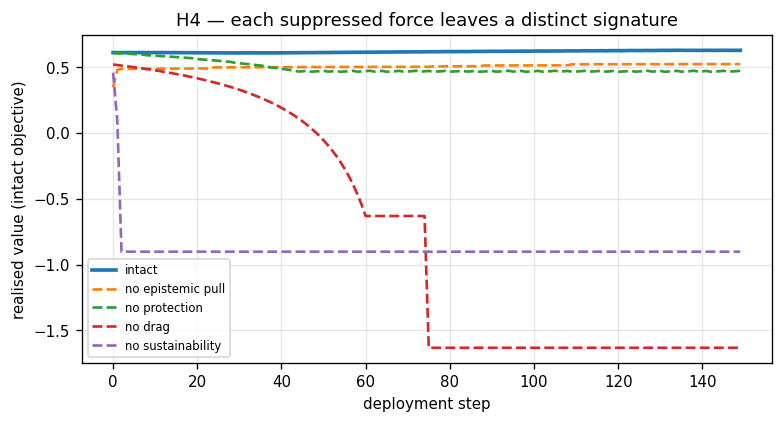

In [8]:
# ============================================================
# 7. H4: ablate one force at a time, observe the failure signature
# ============================================================
MASKS = {"intact":            (1,1,1,1,1),
         "no epistemic pull": (0,1,1,1,1),
         "no protection":     (1,1,1,0,1),
         "no drag":           (1,1,0,1,1),
         "no sustainability": (1,1,1,1,0)}

def deployment_curve(mask, envs, steps=150, R0=0.6):
    out = []
    for R, T, _H in envs[:24]:
        H = float(steps)
        Rt, vals = R0, []
        e, a, _ = best_policy(Rt, T, H, mask)
        for _t in range(steps):
            vals.append(uvif_objective(e, a, max(Rt, 1e-6), T, H))   # intact scoring
            Rt = min(1.0, Rt + REGEN - CS*(e + a))
            if Rt <= 0:
                vals += [vals[-1] - 1.0]*(steps - len(vals)); break  # viability failure
            e, a, _ = best_policy(Rt, T, H, mask)
        out.append(vals[:steps])
    return np.mean(np.array(out), axis=0)

curves = {k: deployment_curve(m, EVAL) for k, m in MASKS.items()}
h4_df = pd.DataFrame({"ablation": list(curves),
                      "t=0":   [f"{c[0]:+.3f}"   for c in curves.values()],
                      "t=10":  [f"{c[10]:+.3f}"  for c in curves.values()],
                      "t=50":  [f"{c[50]:+.3f}"  for c in curves.values()],
                      "t=149": [f"{c[149]:+.3f}" for c in curves.values()],
                      "mean":  [f"{c.mean():+.3f}" for c in curves.values()]})
h4_df.to_csv(TABLE_DIR/"table_H4_failure_signatures.csv", index=False)
log("\n[H4] deployment value under single-force ablation (intact scoring):")
log(h4_df.to_string(index=False))
display(h4_df)

fig, ax = plt.subplots(figsize=(6.6, 3.6))
for k, c in curves.items():
    ax.plot(c, lw=2.2 if k == "intact" else 1.6, ls="-" if k == "intact" else "--", label=k)
ax.set_xlabel("deployment step"); ax.set_ylabel("realised value (intact objective)")
ax.set_title("H4 — each suppressed force leaves a distinct signature")
ax.legend(fontsize=7, loc="lower left")
fig.tight_layout(); fig.savefig(FIG_DIR/"figure_H4_failure_signatures.png", bbox_inches="tight")
plt.show()

## 8. Sensitivity — do these conclusions survive different constants?

The model constants ($\kappa$, $\lambda$, $c_d$, $\rho$, $c_s$, regeneration) were chosen by
the author. A result that holds only at those values is an artifact. Each constant is
perturbed by $\pm 40\%$ and the three surviving qualitative conclusions are re-checked.

In [9]:
# ============================================================
# 8. Sensitivity sweep over every model constant
# ============================================================

BASE = dict(KAPPA=KAPPA, LAM=LAM, CD=CD, RHO=RHO, CS=CS, REGEN=REGEN)

def conclusions_under(**over):
    g = globals(); saved = {k: g[k] for k in BASE}
    g.update(over)
    try:
        # (i) H1: does the UVIF policy vary with state at all?
        pols = np.array([best_policy(R, T, H)[:2] for R, T, H in EVAL])
        h1 = len(np.unique(pols, axis=0)) > 1
        # (ii) H2: does a longer horizon yield a less aggressive policy?
        s = best_policy(0.6, 0.5, 1.0)[:2]; l = best_policy(0.6, 0.5, 150.0)[:2]
        h2 = (l[0] + l[1]) < (s[0] + s[1])
        # (iii) H4: does removing sustainability hurt over a long deployment?
        h4 = deployment_curve(MASKS["no sustainability"], EVAL[:12]).mean() < \
             deployment_curve(MASKS["intact"], EVAL[:12]).mean()
        return h1, h2, h4
    finally:
        g.update(saved)

rows = []
for name, base in BASE.items():
    for mult, tag in ((0.6, "-40%"), (1.0, "base"), (1.4, "+40%")):
        h1, h2, h4 = conclusions_under(**{name: base*mult})
        rows.append({"constant": name, "setting": tag, "value": round(base*mult, 3),
                     "H1 state-dependent": h1, "H2 horizon effect": h2,
                     "H4 sustainability ablation hurts": h4})

sens = pd.DataFrame(rows)
sens.to_csv(TABLE_DIR/"table_sensitivity_analysis.csv", index=False)
log("\n[SENSITIVITY] qualitative conclusions under +/-40% perturbation of each constant:")
log(sens.to_string(index=False))
display(sens)

held = sens[["H1 state-dependent","H2 horizon effect","H4 sustainability ablation hurts"]]
log(f"\n[SENSITIVITY] conclusions holding in all {len(sens)} perturbed settings: "
    + ", ".join(c for c in held.columns if held[c].all()))
log("[SENSITIVITY] conclusions that FAIL somewhere: "
    + (", ".join(c for c in held.columns if not held[c].all()) or "none"))


[SENSITIVITY] qualitative conclusions under +/-40% perturbation of each constant:
constant setting  value  H1 state-dependent  H2 horizon effect  H4 sustainability ablation hurts
   KAPPA    -40%   1.80                True               True                              True
   KAPPA    base   3.00                True               True                              True
   KAPPA    +40%   4.20                True               True                              True
     LAM    -40%   0.21                True               True                              True
     LAM    base   0.35                True               True                              True
     LAM    +40%   0.49                True               True                              True
      CD    -40%   0.33                True               True                              True
      CD    base   0.55                True               True                              True
      CD    +40%   0.77                True 

,constant,setting,value,H1 state-dependent,H2 horizon effect,H4 sustainability ablation hurts
0,KAPPA,-40%,1.80,True,True,True
1,KAPPA,base,3.00,True,True,True
2,KAPPA,+40%,4.20,True,True,True
3,LAM,-40%,0.21,True,True,True
4,LAM,base,0.35,True,True,True
5,LAM,+40%,0.49,True,True,True
6,CD,-40%,0.33,True,True,True
7,CD,base,0.55,True,True,True
8,CD,+40%,0.77,True,True,True
9,RHO,-40%,0.54,True,True,True



[SENSITIVITY] conclusions holding in all 18 perturbed settings: H1 state-dependent, H2 horizon effect, H4 sustainability ablation hurts
[SENSITIVITY] conclusions that FAIL somewhere: none


## 9. Summary

In [10]:
# ============================================================
# 9. Summary table and artefact manifest
# ============================================================
summary = pd.DataFrame([
 {"prediction": "H1 state-dependent force weighting",
  "verdict": "supported in-model",
  "evidence": f"best fixed-weight agent's held-out error is {mse_eval/var_eval:.2f}x the "
              f"mean-policy baseline, i.e. worse than predicting the mean; UVIF plays "
              f"{len(np.unique(uvif_eval,axis=0))} distinct policies, the comparator 1"},
 {"prediction": "H2 sustainability beyond the episode",
  "verdict": "supported in-model",
  "evidence": f"sustained-regime policy is locally suboptimal by {v_s-v_l:.3f} per episode "
              f"yet remains viable, while the single-episode policy fails at step "
              f"{int(np.argmax(traj_s<=0))}"},
 {"prediction": "H3 irreversibility not a large negative utility",
  "verdict": "supported only in the narrow form",
  "evidence": f"best monotone penalty leaves {h3_df['unexplained %'].iloc[-1]}% unexplained "
              f"with b* running to the search ceiling; approximates the constraint as "
              f"b -> infinity, so only the finite-coefficient claim is defensible"},
 {"prediction": "H4 per-force failure signatures",
  "verdict": "supported in-model",
  "evidence": "four ablations give four distinguishable curves; drag and sustainability "
              "ablations end in viability failure, protection degrades, epistemic ablation "
              "is stable but persistently below intact"},
])
summary.to_csv(TABLE_DIR/"table_summary_H1_H4.csv", index=False)
log("\n[SUMMARY]"); log(summary.to_string(index=False))
display(summary)

manifest = {"project": PROJECT_NAME, "seed": SEED,
            "n_calibration_envs": int(len(CALIB)), "n_evaluation_envs": int(len(EVAL)),
            "constants": {k: float(v) for k, v in BASE.items()}, "P_MAX": float(P_MAX),
            "figures": sorted(p.name for p in FIG_DIR.glob("*.png")),
            "tables":  sorted(p.name for p in TABLE_DIR.glob("*.csv"))}
(OTHER_DIR/"experiment_manifest.json").write_text(json.dumps(manifest, indent=2))
log("\n[FILES] " + json.dumps(manifest["figures"] + manifest["tables"]))
log(f"[DONE] outputs written to {BASE_DIR}")


[SUMMARY]
                                     prediction                           verdict                                                                                                                                                                                     evidence
             H1 state-dependent force weighting                supported in-model                           best fixed-weight agent's held-out error is 1.52x the mean-policy baseline, i.e. worse than predicting the mean; UVIF plays 33 distinct policies, the comparator 1
           H2 sustainability beyond the episode                supported in-model                                                       sustained-regime policy is locally suboptimal by 0.374 per episode yet remains viable, while the single-episode policy fails at step 1
H3 irreversibility not a large negative utility supported only in the narrow form       best monotone penalty leaves 10.5% unexplained with b* running to the search ceiling; ap

,prediction,verdict,evidence
0,H1 state-dependent force weighting,supported in-model,best fixed-weight agent's held-out error is 1....
1,H2 sustainability beyond the episode,supported in-model,sustained-regime policy is locally suboptimal ...
2,H3 irreversibility not a large negative utility,supported only in the narrow form,best monotone penalty leaves 10.5% unexplained...
3,H4 per-force failure signatures,supported in-model,four ablations give four distinguishable curve...



[FILES] ["figure_H1_state_dependent_weighting.png", "figure_H2_horizon_contrast.png", "figure_H4_failure_signatures.png", "table_H3_monotone_penalty_fits.csv", "table_H4_failure_signatures.csv", "table_sensitivity_analysis.csv", "table_summary_H1_H4.csv"]
[DONE] outputs written to Outputs/UVIF_CognitiveEquilibrium_Article2


## 10. Claim boundary

What may be written into the manuscript on the strength of this notebook:

* H1, H2 and H4 are **well-posed and internally coherent**: each names a measurable
  signature, and the framework produces that signature while a natural comparator does not.
  The sensitivity sweep in Section 8 reports which of these survive perturbation of the
  model constants.
* H3 holds **only in its narrow form** — no *finite* monotone rescaling reproduces
  constrained choice. The unrestricted claim is false in the limit and must not be made.
* The first H3 implementation failed, and the failure is documented in Section 5 rather
  than removed.

What may **not** be written:

* Nothing here is evidence about human or animal cognition. The functional forms were chosen
  by the author, and a simulation cannot confirm a prediction about real cognitive systems.
* The manuscript's statement in Section 10 — that the paper reports no experiments and that
  UVIF should be read as a research programme rather than a validated account — **remains
  accurate and should stay**. This notebook is an illustrative simulation of the framework's
  own dynamics; it is not the empirical test that Section 10 calls for.